# 双十一淘宝美妆数据

### 基本信息

In [3]:
import os

import pandas as pd
import numpy as np
os.chdir('E:\\JupyterProject')
df=pd.read_csv('data/双十一淘宝美妆数据.csv')
df.head()


,update_time,id,title,price,sale_count,comment_count,店名
0,2016/11/14,A18164178225,CHANDO/自然堂 雪域精粹纯粹滋润霜50g 补水保湿 滋润水润面霜,139.0,26719.0,2704.0,自然堂
1,2016/11/14,A18177105952,CHANDO/自然堂凝时鲜颜肌活乳液120ML 淡化细纹补水滋润专柜正品,194.0,8122.0,1492.0,自然堂
2,2016/11/14,A18177226992,CHANDO/自然堂活泉保湿修护精华水（滋润型135ml 补水控油爽肤水,99.0,12668.0,589.0,自然堂
3,2016/11/14,A18178033846,CHANDO/自然堂 男士劲爽控油洁面膏 100g 深层清洁 男士洗面奶,38.0,25805.0,4287.0,自然堂
4,2016/11/14,A18178045259,CHANDO/自然堂雪域精粹纯粹滋润霜（清爽型）50g补水保湿滋润霜,139.0,5196.0,618.0,自然堂


In [4]:
#1.读取数据
df.info()
#2统计店铺信息
df.店名.value_counts()



<class 'pandas.DataFrame'>
RangeIndex: 27598 entries, 0 to 27597
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   update_time    27598 non-null  str    
 1   id             27598 non-null  str    
 2   title          27598 non-null  str    
 3   price          27598 non-null  float64
 4   sale_count     25244 non-null  float64
 5   comment_count  25244 non-null  float64
 6   店名             27598 non-null  str    
dtypes: float64(3), str(4)
memory usage: 1.5 MB


店名
悦诗风吟    3021
佰草集     2265
欧莱雅     1974
雅诗兰黛    1810
倩碧      1704
美加净     1678
欧珀莱     1359
妮维雅     1329
相宜本草    1313
兰蔻      1285
娇兰      1193
自然堂     1190
玉兰油     1135
兰芝      1091
美宝莲      825
资生堂      821
植村秀      750
薇姿       746
雅漾       663
雪花秀      543
SKII     469
蜜丝佛陀     434
Name: count, dtype: int64

### 数据清洗

In [5]:
#统计重复数据进行清洗
print(df.shape)
df=df.drop_duplicates(inplace=False)
print(df.shape)
#改变索引
print(df.index)
df=df.reset_index(drop=True)
print('新索引',df.index)


(27598, 7)
(27512, 7)
Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       27588, 27589, 27590, 27591, 27592, 27593, 27594, 27595, 27596, 27597],
      dtype='int64', length=27512)
新索引 RangeIndex(start=0, stop=27512, step=1)


In [6]:
#查看缺失值
df.isnull().any()
df.describe()

,price,sale_count,comment_count
count,27512.000000,2.516200e+04,25162.000000
mean,363.423512,1.231605e+04,1121.741197
std,614.876153,5.241236e+04,5277.781581
min,1.000000,0.000000e+00,0.000000
25%,99.000000,2.780000e+02,21.000000
50%,205.000000,1.443000e+03,153.000000
75%,390.000000,6.353000e+03,669.000000
max,11100.000000,1.923160e+06,202930.000000


In [7]:
mode1=df.sale_count.mode()
print(mode1)
#销售量和评论可能为零的情况
mode2=df.comment_count.mode()
print(mode2)

0    0.0
Name: sale_count, dtype: float64
0    0.0
Name: comment_count, dtype: float64


In [8]:
df=df.fillna(0)
df.isna().sum()

update_time      0
id               0
title            0
price            0
sale_count       0
comment_count    0
店名               0
dtype: int64

In [9]:
# 确保 df 是去import jieb重并重置索引后的数据（假设 df 已经是清洗后的）a
title_cut = []
for i in df['title']:
    j = list(jieba.cut(i))   # 使用 cut 代替 lcut
    title_cut.append(j)
df['item_name_cut'] = title_cut

Building prefix dict from E:\JupyterProject\.venv\Lib\site-packages\jieba\dict.txt ...
Dumping model to file cache C:\Users\ASUS\AppData\Local\Temp\jieba.cache
Loading model cost 1.6459252834320068 seconds.
Prefix dict has been built succesfully.


In [10]:
# 给商品添加分类
basic_config_df = """护肤品    套装    套装
护肤品    乳液类    乳液    美白乳    润肤乳    凝乳    柔肤液'    亮肤乳    菁华乳    修护乳
护肤品    眼部护理    眼霜    眼部精华    眼膜
护肤品    面膜类    面膜
护肤品    清洁类    洗面    洁面    清洁    卸妆    洁颜    洗颜    去角质    磨砂
护肤品    化妆水    化妆水    爽肤水    柔肤水    补水露    凝露    柔肤液    精粹水    亮肤水    润肤水    保湿水    菁华水    保湿喷雾    舒缓喷雾
护肤品    面霜类    面霜    日霜    晚霜    柔肤霜    滋润霜    保湿霜    凝霜    日间霜    晚间霜    乳霜    修护霜    亮肤霜    底霜    菁华霜
护肤品    精华类    精华液    精华水    精华露    精华素
护肤品    防晒类    防晒霜    防晒喷雾
化妆品    口红类    唇釉    口红    唇彩
化妆品    底妆类    散粉    蜜粉    粉底液    定妆粉     气垫    粉饼    BB    CC    遮瑕    粉霜    粉底膏    粉底霜
化妆品    眼部彩妆    眉粉    染眉膏    眼线    眼影    睫毛膏
化妆品    修容类    鼻影    修容粉    高光    腮红
其他    其他    其他"""
category_config_map = {}
for config_line in basic_config_df.split('\n'):
    basic_cateogry_list = config_line.strip().strip('\n').strip('    ').split('    ')
    main_category = basic_cateogry_list[0]
    sub_category = basic_cateogry_list[1]
    unit_category_list = basic_cateogry_list[2:-1]
    for unit_category in unit_category_list:
        if unit_category and unit_category.strip().strip('    '):
            category_config_map[unit_category] = (main_category,sub_category)

category_config_map

{'乳液': ('护肤品', '乳液类'),
 '美白乳': ('护肤品', '乳液类'),
 '润肤乳': ('护肤品', '乳液类'),
 '凝乳': ('护肤品', '乳液类'),
 "柔肤液'": ('护肤品', '乳液类'),
 '亮肤乳': ('护肤品', '乳液类'),
 '菁华乳': ('护肤品', '乳液类'),
 '眼霜': ('护肤品', '眼部护理'),
 '眼部精华': ('护肤品', '眼部护理'),
 '洗面': ('护肤品', '清洁类'),
 '洁面': ('护肤品', '清洁类'),
 '清洁': ('护肤品', '清洁类'),
 '卸妆': ('护肤品', '清洁类'),
 '洁颜': ('护肤品', '清洁类'),
 '洗颜': ('护肤品', '清洁类'),
 '去角质': ('护肤品', '清洁类'),
 '化妆水': ('护肤品', '化妆水'),
 '爽肤水': ('护肤品', '化妆水'),
 '柔肤水': ('护肤品', '化妆水'),
 '补水露': ('护肤品', '化妆水'),
 '凝露': ('护肤品', '化妆水'),
 '柔肤液': ('护肤品', '化妆水'),
 '精粹水': ('护肤品', '化妆水'),
 '亮肤水': ('护肤品', '化妆水'),
 '润肤水': ('护肤品', '化妆水'),
 '保湿水': ('护肤品', '化妆水'),
 '菁华水': ('护肤品', '化妆水'),
 '保湿喷雾': ('护肤品', '化妆水'),
 '面霜': ('护肤品', '面霜类'),
 '日霜': ('护肤品', '面霜类'),
 '晚霜': ('护肤品', '面霜类'),
 '柔肤霜': ('护肤品', '面霜类'),
 '滋润霜': ('护肤品', '面霜类'),
 '保湿霜': ('护肤品', '面霜类'),
 '凝霜': ('护肤品', '面霜类'),
 '日间霜': ('护肤品', '面霜类'),
 '晚间霜': ('护肤品', '面霜类'),
 '乳霜': ('护肤品', '面霜类'),
 '修护霜': ('护肤品', '面霜类'),
 '亮肤霜': ('护肤品', '面霜类'),
 '底霜': ('护肤品', '面霜类'),
 '精华液': ('护肤品', '精华类'),
 '精

In [11]:
def func1(row):
    sub_type=""
    main_type=""
    exist=False
    for temp in row:
       if temp in category_config_map:
           main_type = category_config_map[temp][0]   # 主类别
           sub_type = category_config_map[temp][1]
           exist=True
           break
    if not(exist):
           sub_type="other"
           main_type="other"
    return [sub_type,main_type]

In [12]:
df['sub_type']=df['item_name_cut'].map(lambda r:func1(r)[0])
df['main_type']=df['item_name_cut'].map(lambda r:func1(r)[1])
df.head()

,update_time,id,title,price,sale_count,comment_count,店名,item_name_cut,sub_type,main_type
0,2016/11/14,A18164178225,CHANDO/自然堂 雪域精粹纯粹滋润霜50g 补水保湿 滋润水润面霜,139.0,26719.0,2704.0,自然堂,"[CHANDO, /, 自然, 堂, , 雪域, 精粹, 纯粹, 滋润霜, 50g, ,...",面霜类,护肤品
1,2016/11/14,A18177105952,CHANDO/自然堂凝时鲜颜肌活乳液120ML 淡化细纹补水滋润专柜正品,194.0,8122.0,1492.0,自然堂,"[CHANDO, /, 自然, 堂, 凝, 时鲜, 颜肌活, 乳液, 120ML, , 淡...",乳液类,护肤品
2,2016/11/14,A18177226992,CHANDO/自然堂活泉保湿修护精华水（滋润型135ml 补水控油爽肤水,99.0,12668.0,589.0,自然堂,"[CHANDO, /, 自然, 堂, 活泉, 保湿, 修护, 精华, 水, （, 滋润, 型...",化妆水,护肤品
3,2016/11/14,A18178033846,CHANDO/自然堂 男士劲爽控油洁面膏 100g 深层清洁 男士洗面奶,38.0,25805.0,4287.0,自然堂,"[CHANDO, /, 自然, 堂, , 男士, 劲爽, 控油, 洁面膏, , 100g...",清洁类,护肤品
4,2016/11/14,A18178045259,CHANDO/自然堂雪域精粹纯粹滋润霜（清爽型）50g补水保湿滋润霜,139.0,5196.0,618.0,自然堂,"[CHANDO, /, 自然, 堂, 雪域, 精粹, 纯粹, 滋润霜, （, 清爽型, ）,...",面霜类,护肤品


In [13]:
# 将“是否男士专用”新增为一列
gender = []
for i in range(len(df)):
    if '男' in df.item_name_cut[i]:
        gender.append('是')
    elif '男士' in df.item_name_cut[i]:
        gender.append('是')
    elif '男生' in df.item_name_cut[i]:
        gender.append('是')
    else:
        gender.append('否')

# 将“是否男士专用”新增为一列
df['是否男士专用'] = gender
df.head()


,update_time,id,title,price,sale_count,comment_count,店名,item_name_cut,sub_type,main_type,是否男士专用
0,2016/11/14,A18164178225,CHANDO/自然堂 雪域精粹纯粹滋润霜50g 补水保湿 滋润水润面霜,139.0,26719.0,2704.0,自然堂,"[CHANDO, /, 自然, 堂, , 雪域, 精粹, 纯粹, 滋润霜, 50g, ,...",面霜类,护肤品,否
1,2016/11/14,A18177105952,CHANDO/自然堂凝时鲜颜肌活乳液120ML 淡化细纹补水滋润专柜正品,194.0,8122.0,1492.0,自然堂,"[CHANDO, /, 自然, 堂, 凝, 时鲜, 颜肌活, 乳液, 120ML, , 淡...",乳液类,护肤品,否
2,2016/11/14,A18177226992,CHANDO/自然堂活泉保湿修护精华水（滋润型135ml 补水控油爽肤水,99.0,12668.0,589.0,自然堂,"[CHANDO, /, 自然, 堂, 活泉, 保湿, 修护, 精华, 水, （, 滋润, 型...",化妆水,护肤品,否
3,2016/11/14,A18178033846,CHANDO/自然堂 男士劲爽控油洁面膏 100g 深层清洁 男士洗面奶,38.0,25805.0,4287.0,自然堂,"[CHANDO, /, 自然, 堂, , 男士, 劲爽, 控油, 洁面膏, , 100g...",清洁类,护肤品,是
4,2016/11/14,A18178045259,CHANDO/自然堂雪域精粹纯粹滋润霜（清爽型）50g补水保湿滋润霜,139.0,5196.0,618.0,自然堂,"[CHANDO, /, 自然, 堂, 雪域, 精粹, 纯粹, 滋润霜, （, 清爽型, ）,...",面霜类,护肤品,否


In [14]:
df['销售额']=df.sale_count*df.price
df['update_time']=pd.to_datetime(df['update_time'])
df[['update_time']].head()

,update_time
0,2016-11-14
1,2016-11-14
2,2016-11-14
3,2016-11-14
4,2016-11-14


In [15]:
# 将时间设置为新的index
df= df.set_index('update_time')

# 新增时间“天”为一列
df['day'] = df.index.day

# 删除中文分词的一列
del df['item_name_cut']
# 查看最终数据表格



In [16]:
# 查看最终数据表格
df.head()

,id,title,price,sale_count,comment_count,店名,sub_type,main_type,是否男士专用,销售额,day
update_time,,,,,,,,,,,
2016-11-14,A18164178225,CHANDO/自然堂 雪域精粹纯粹滋润霜50g 补水保湿 滋润水润面霜,139.0,26719.0,2704.0,自然堂,面霜类,护肤品,否,3713941.0,14
2016-11-14,A18177105952,CHANDO/自然堂凝时鲜颜肌活乳液120ML 淡化细纹补水滋润专柜正品,194.0,8122.0,1492.0,自然堂,乳液类,护肤品,否,1575668.0,14
2016-11-14,A18177226992,CHANDO/自然堂活泉保湿修护精华水（滋润型135ml 补水控油爽肤水,99.0,12668.0,589.0,自然堂,化妆水,护肤品,否,1254132.0,14
2016-11-14,A18178033846,CHANDO/自然堂 男士劲爽控油洁面膏 100g 深层清洁 男士洗面奶,38.0,25805.0,4287.0,自然堂,清洁类,护肤品,是,980590.0,14
2016-11-14,A18178045259,CHANDO/自然堂雪域精粹纯粹滋润霜（清爽型）50g补水保湿滋润霜,139.0,5196.0,618.0,自然堂,面霜类,护肤品,否,722244.0,14


In [17]:
# 保存清理好的数据为Excel格式
df.to_excel('./clean_beautymakeup.xlsx',sheet_name='clean_data')

# 3数据探索

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
df.columns


Index(['id', 'title', 'price', 'sale_count', 'comment_count', '店名', 'sub_type',
       'main_type', '是否男士专用', '销售额', 'day'],
      dtype='str')

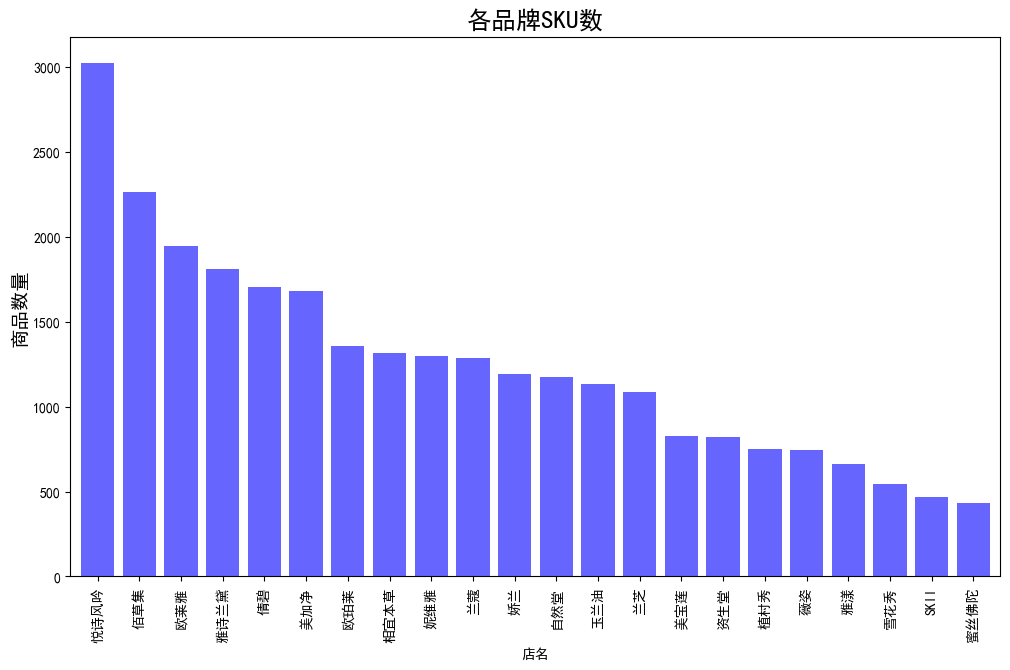

In [24]:
plt.rcParams['font.sans-serif']=['SimHei']  #指定默认字体
plt.rcParams['axes.unicode_minus']=False  #解决负号'-'显示为方块的问题

plt.figure(figsize=(12,7))
# 计算各店铺的商品数量
df['店名'].value_counts().sort_values(ascending=False).plot.bar(width=0.8,alpha=0.6,color='b')

plt.title('各品牌SKU数',fontsize=18)
plt.ylabel('商品数量',fontsize=14)
plt.show()
